# Phase 1 Overview Notebook: Ingestion & Data Stream Alignment

This notebook provides an interactive environment to inspect, visualize, and validate the Phase 1 v2 ingested data streams:
1. **Stream A (Twitter Social Media Stream)**: Candidate hashtag streams for Donald Trump and Joe Biden.
2. **Stream B (Exogenous Events)**: Curated timeline of key political shocks.
3. **Stream C (Electoral Benchmarks & Demographics)**: Certified 2020 election returns enriched with historical classifications and demographic covariates ($Z_{ki}$).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set plot styling
sns.set_theme(style="whitegrid", context="notebook")
PROJECT_ROOT = Path("..").resolve()
PHASE1_DATA_DIR = PROJECT_ROOT / "data" / "02_interim" / "phase1_v2"
print(f"Project Root: {PROJECT_ROOT}")
print(f"Phase 1 Data Directory: {PHASE1_DATA_DIR}")

Project Root: D:\GW_UNIVERSITY\AIS\Social_Listener\Env\Social_Listener_V1\UOG_AIS_SOCIAL_LISTENER
Phase 1 Data Directory: D:\GW_UNIVERSITY\AIS\Social_Listener\Env\Social_Listener_V1\UOG_AIS_SOCIAL_LISTENER\data\02_interim\phase1_v2


## 1. Load Stream A: Twitter Data Streams

In [2]:
trump_df = pd.read_parquet(PHASE1_DATA_DIR / "twitter_donald_trump_v2.parquet")
biden_df = pd.read_parquet(PHASE1_DATA_DIR / "twitter_joe_biden_v2.parquet")

print(f"Donald Trump Stream Rows: {len(trump_df):,}")
print(f"Joe Biden Stream Rows:     {len(biden_df):,}")
print(f"Total Raw Twitter Rows:    {len(trump_df) + len(biden_df):,}")

Donald Trump Stream Rows: 970,765
Joe Biden Stream Rows:     776,777
Total Raw Twitter Rows:    1,747,542


In [3]:
# Inspect Twitter Schema
trump_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 970765 entries, 0 to 970764
Data columns (total 29 columns):
 #   Column                Non-Null Count   Dtype              
---  ------                --------------   -----              
 0   tweet_id              970765 non-null  object             
 1   id                    970765 non-null  object             
 2   created_at            970765 non-null  datetime64[ms, UTC]
 3   date                  970765 non-null  datetime64[ms, UTC]
 4   tweet                 970765 non-null  object             
 5   likes                 970765 non-null  float64            
 6   retweet_count         970765 non-null  float64            
 7   retweets              970765 non-null  float64            
 8   replies               0 non-null       object             
 9   source                970765 non-null  object             
 10  user_id               970765 non-null  object             
 11  user_name             970765 non-null  object       

## 2. Visualize Twitter Daily Volume (Oct 15 - Nov 8)

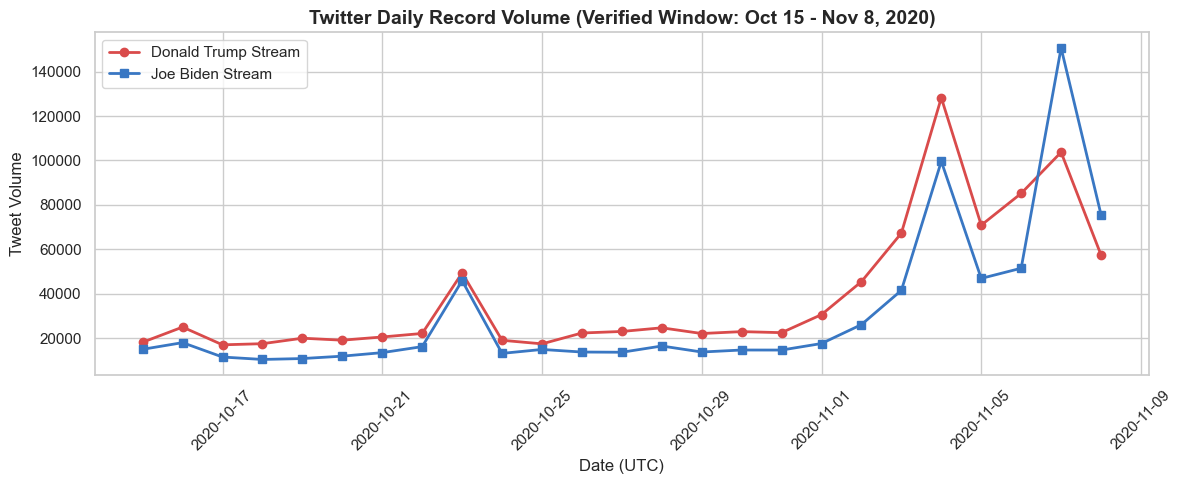

In [4]:
trump_df["date_only"] = pd.to_datetime(trump_df["created_at"]).dt.date
biden_df["date_only"] = pd.to_datetime(biden_df["created_at"]).dt.date

t_daily = trump_df.groupby("date_only").size().reset_index(name="Trump")
b_daily = biden_df.groupby("date_only").size().reset_index(name="Biden")

daily_df = pd.merge(t_daily, b_daily, on="date_only", how="outer").sort_values("date_only")

plt.figure(figsize=(12, 5))
plt.plot(daily_df["date_only"], daily_df["Trump"], label="Donald Trump Stream", color="#D94B4B", marker="o", linewidth=2)
plt.plot(daily_df["date_only"], daily_df["Biden"], label="Joe Biden Stream", color="#3977C3", marker="s", linewidth=2)
plt.title("Twitter Daily Record Volume (Verified Window: Oct 15 - Nov 8, 2020)", fontsize=14, fontweight="bold")
plt.xlabel("Date (UTC)", fontsize=12)
plt.ylabel("Tweet Volume", fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 3. Load Stream B: Political Events Timeline

In [5]:
events_df = pd.read_parquet(PHASE1_DATA_DIR / "political_events_v2.parquet")
events_df

,event_id,event_timestamp_utc,event_timezone,event_name,event_category,event_description,source_url,event_window_protocol_status,observation_level_indicators
0,town_halls_2020_10_15,2020-10-16 00:00:00+00:00,America/New_York,Dueling presidential town halls,campaign_event,Joe Biden and Donald Trump participated in sep...,https://www.politifact.com/article/2020/oct/15...,pending_D4,derive_in_phase4
1,presidential_debate_2020_10_22,2020-10-23 01:00:00+00:00,America/New_York,Final presidential debate,debate,Joe Biden and Donald Trump participated in the...,https://www.debates.org/debate-history/2020-de...,pending_D4,derive_in_phase4
2,election_day_2020_11_03,2020-11-03 05:00:00+00:00,America/New_York,2020 presidential election day,election_day,The 2020 presidential general election was hel...,https://www.fec.gov/resources/cms-content/docu...,pending_D4,derive_in_phase4
3,ap_projection_2020_11_07,2020-11-07 16:26:00+00:00,America/New_York,AP projects Joe Biden as president-elect,projection,The Associated Press declared Joe Biden the wi...,https://www.ap.org/the-definitive-source/behin...,pending_D4,derive_in_phase4


## 4. Load Stream C: Enriched Electoral Returns & Demographic Controls ($Z_{ki}$)

In [6]:
returns_df = pd.read_parquet(PHASE1_DATA_DIR / "electoral_returns_v2.parquet")
print(f"Electoral Returns Rows: {len(returns_df)} (50 States + DC)")
returns_df.head(10)

Electoral Returns Rows: 51 (50 States + DC)


,state_code,biden_votes_2020,trump_votes_2020,total_votes_2020,other_votes_2020,biden_vote_share_pct_2020,trump_vote_share_pct_2020,democratic_margin_pct_2020,absolute_margin_pct_2020,winner_2020,...,historical_classification,median_age,median_income,urbanization_index,ba_education_pct,hispanic_latino_pct,historical_2012_2016_classification_available,demographic_controls_available,swing_threshold_pct,source_url
0,AK,153778,189951,359530,15801,42.771952,52.833143,-10.061191,10.061191,Trump,...,safe_red,34.6,77790.0,64.9,30.2,7.3,True,True,5.0,https://www.fec.gov/resources/cms-content/docu...
1,AL,849624,1441170,2323282,32488,36.569990,62.031643,-25.461653,25.461653,Trump,...,safe_red,39.2,51734.0,59.0,26.2,4.6,True,True,5.0,https://www.fec.gov/resources/cms-content/docu...
2,AR,423932,760647,1219069,34490,34.775062,62.395730,-27.620668,27.620668,Trump,...,safe_red,38.3,48952.0,56.2,23.3,7.8,True,True,5.0,https://www.fec.gov/resources/cms-content/docu...
3,AZ,1672143,1661686,3387326,53497,49.364691,49.055981,0.308710,0.308710,Biden,...,battleground,38.0,62055.0,89.8,30.2,31.7,True,True,5.0,https://www.fec.gov/resources/cms-content/docu...
4,CA,11110250,6006429,17500881,384202,63.483947,34.320724,29.163223,29.163223,Biden,...,safe_blue,37.0,78672.0,95.0,33.9,39.4,True,True,5.0,https://www.fec.gov/resources/cms-content/docu...
5,CO,1804352,1364607,3256980,88021,55.399542,41.897924,13.501618,13.501618,Biden,...,safe_blue,37.1,77127.0,86.2,40.9,21.8,True,True,5.0,https://www.fec.gov/resources/cms-content/docu...
6,CT,1080831,714717,1823857,28309,59.260732,39.187118,20.073613,20.073613,Biden,...,safe_blue,41.1,78833.0,88.0,39.8,16.9,True,True,5.0,https://www.fec.gov/resources/cms-content/docu...
7,DC,317323,18586,344356,8447,92.149694,5.397321,86.752373,86.752373,Biden,...,safe_blue,34.2,92266.0,100.0,58.5,11.3,True,True,5.0,https://www.fec.gov/resources/cms-content/docu...
8,DE,296268,200603,504346,7475,58.743006,39.774877,18.968129,18.968129,Biden,...,safe_blue,41.0,70176.0,83.3,32.0,9.6,True,True,5.0,https://www.fec.gov/resources/cms-content/docu...
9,FL,5297045,5668731,11067456,101680,47.861451,51.219820,-3.358369,3.358369,Trump,...,battleground,42.4,57703.0,91.2,30.7,26.5,True,True,5.0,https://www.fec.gov/resources/cms-content/docu...


In [7]:
# Classification breakdown: Battleground vs Safe
returns_df["historical_classification"].value_counts()

historical_classification
safe_red        23
safe_blue       18
battleground    10
Name: count, dtype: int64